In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import kaleido

plt.style.use("default")
sns.set_theme(style="whitegrid")



In [44]:
import pandas as pd

fund_master = pd.read_csv(
    r"D:\Bluestock-project\data\processed\01_fund_master_cleaned.csv"
)

nav_history = pd.read_csv(
    r"D:\Bluestock-project\data\processed\02_nav_history_cleaned.csv"
)

aum_by_fund_house= pd.read_csv(
    r"D:\Bluestock-project\data\processed\03_aum_by_fund_house_cleaned.csv"
)

monthly_sip_inflows = pd.read_csv(
    r"D:\Bluestock-project\data\processed\04_monthly_sip_inflows_cleaned.csv"
)

category_inflows = pd.read_csv(
    r"D:\Bluestock-project\data\processed\05_category_inflows_cleaned.csv"
)

folios = pd.read_csv(
    r"D:\Bluestock-project\data\processed\06_industry_folio_count_cleaned.csv"
)

performance = pd.read_csv(
    r"D:\Bluestock-project\data\processed\07_scheme_performance_cleaned.csv"
)

transactions = pd.read_csv(
    r"D:\Bluestock-project\data\processed\08_investor_transactions_cleaned.csv"
)

holdings = pd.read_csv(
    r"D:\Bluestock-project\data\processed\09_portfolio_holdings_cleaned.csv"
)

benchmark = pd.read_csv(
    r"D:\Bluestock-project\data\processed\10_benchmark_indices_cleaned.csv"
)


In [25]:
import os

os.makedirs("reports/charts", exist_ok=True)

def save_chart(name):
    plt.savefig(
        f"reports/charts/{name}.png",
        dpi=300,
        bbox_inches="tight"
    )

In [26]:
nav_history["date"] = pd.to_datetime(nav_history["date"])
nav_plot = nav_history.merge(
    fund_master[["amfi_code","scheme_name"]],
    on="amfi_code",
    how="left"
)

In [27]:
fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend (2022-2026)"
)

fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    fillcolor="green",
    opacity=0.15
)

fig.add_vrect(
    x0="2024-03-01",
    x1="2024-06-30",
    annotation_text="2024 Correction",
    fillcolor="red",
    opacity=0.15
)


fig.show()

In [28]:
aum_by_fund_house["year"] = pd.to_datetime(aum_by_fund_house["date"]).dt.year

annual_aum = (
    aum_by_fund_house.groupby(["year","fund_house"])
       ["aum_lakh_crore"]
       .mean()
       .reset_index()
)

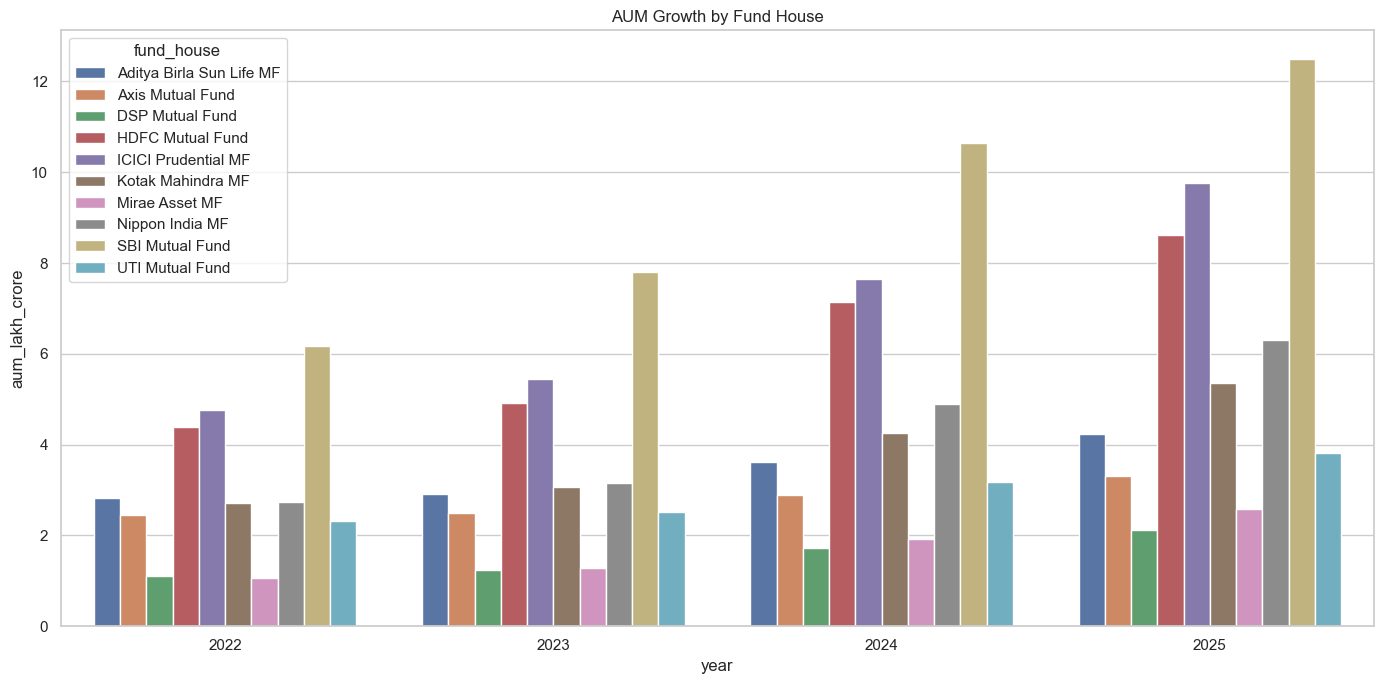

In [29]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=annual_aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House")
plt.tight_layout()
save_chart("02_aum_growth.png")
plt.show()

In [30]:
monthly_sip_inflows["month"] = pd.to_datetime(monthly_sip_inflows["month"])

In [31]:
fig = px.line(
    monthly_sip_inflows,
    x="month",
    y="sip_inflow_crore",
    markers=True
)
fig

In [32]:
peak = monthly_sip_inflows.loc[monthly_sip_inflows["sip_inflow_crore"].idxmax()]
fig.add_annotation(
    x=peak["month"],
    y=peak["sip_inflow_crore"],
    text="₹31,002 Cr Peak",
    showarrow=True
)


fig.show()

In [33]:
pivot = category_inflows.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)
pivot

month,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0
Large Cap,2413.0,2076.0,2519.0,2574.0,1940.0,1879.0,2255.0,1870.0,1923.0,2025.0,1925.0,2234.0
Liquid,37537.0,41872.0,40486.0,34643.0,41952.0,35308.0,39091.0,40506.0,34933.0,33892.0,32374.0,38681.0
Mid Cap,3897.0,5300.0,5047.0,4548.0,3899.0,4960.0,4106.0,4336.0,5023.0,4316.0,4819.0,5061.0
Sectoral/Thematic,8052.0,8354.0,10030.0,9896.0,8360.0,8518.0,7680.0,7397.0,9820.0,7893.0,9215.0,8614.0


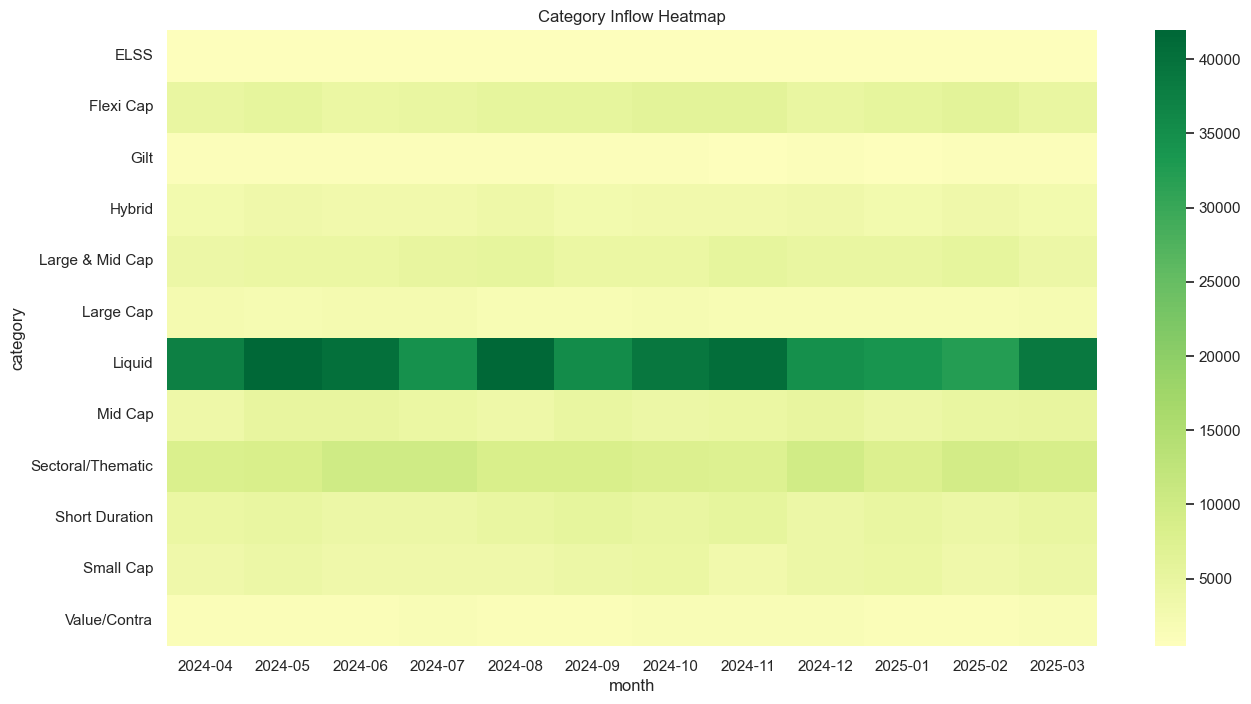

In [34]:
plt.figure(figsize=(15,8))

sns.heatmap(
    pivot,
    cmap="RdYlGn",
    center=0
)

plt.title("Category Inflow Heatmap")
save_chart("04_category_heatmap.png")
plt.show()

In [35]:
age_dist = transactions["age_group"].value_counts()

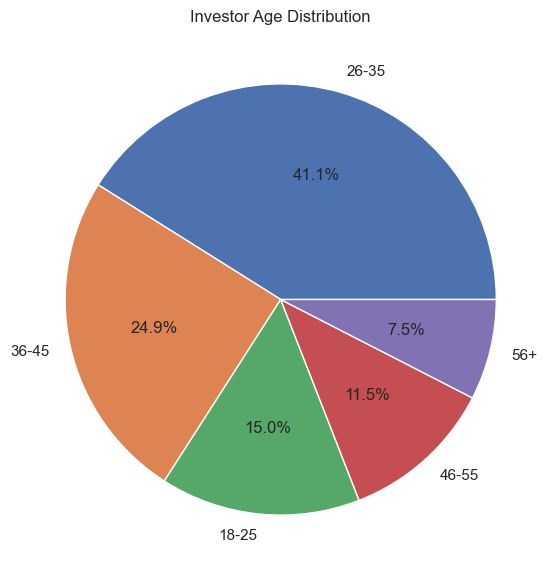

In [36]:
plt.figure(figsize=(7,7))

plt.pie(
    age_dist,
    labels=age_dist.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Distribution")
save_chart("05_age_distribution.png")
plt.show()

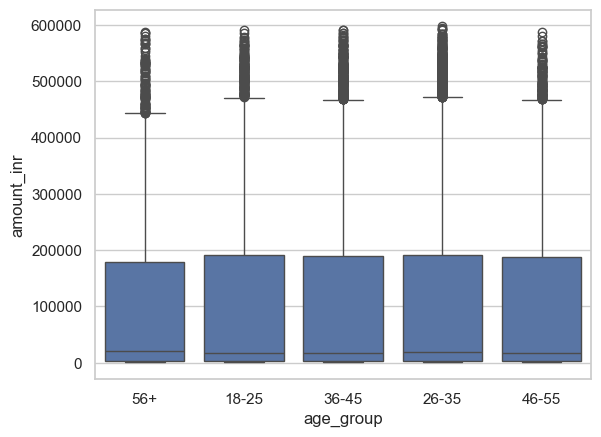

In [37]:
sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)
save_chart("06_age_boxplot.png")

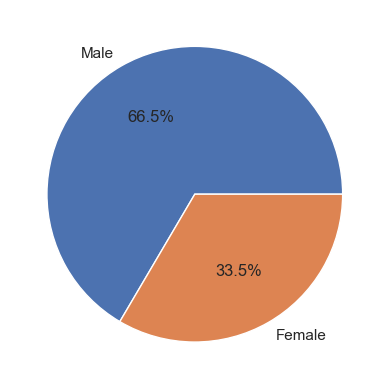

In [38]:
gender = transactions["gender"].value_counts()

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%"
)
save_chart("07_gender_split.png")

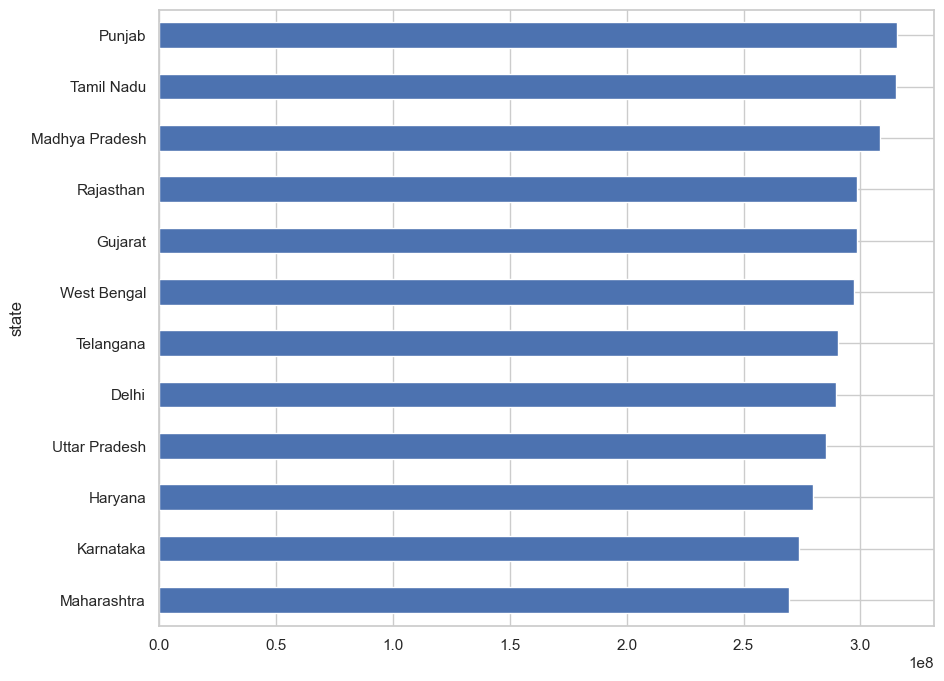

In [39]:
state_sip = (
    transactions.groupby("state")
    ["amount_inr"]
    .sum()
    .sort_values()
)
state_sip.plot(
    kind="barh",
    figsize=(10,8)
)
save_chart("08_state_distribution.png")

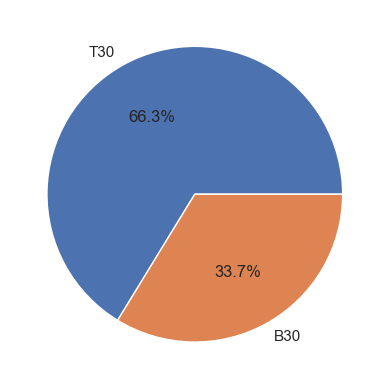

In [40]:
tier = transactions["city_tier"].value_counts()
plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%"
)
save_chart("09_t30_b30_split.png")

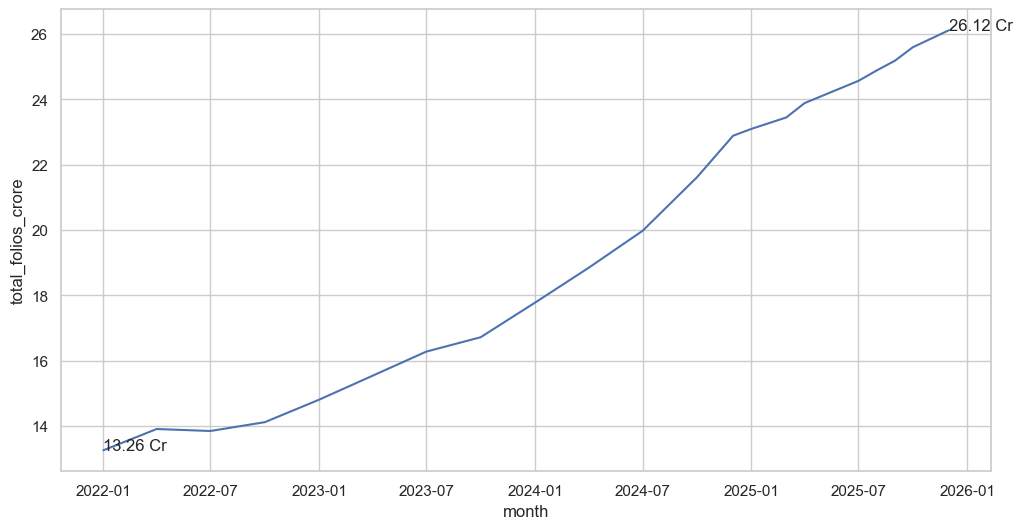

In [45]:
folios["month"] = pd.to_datetime(folios["month"])
plt.figure(figsize=(12,6))

sns.lineplot(
    data=folios,
    x="month",
    y="total_folios_crore"
)
plt.annotate(
    "13.26 Cr",
    xy=(folios.iloc[0]["month"],
        folios.iloc[0]["total_folios_crore"])
)
plt.annotate(
    "26.12 Cr",
    xy=(folios.iloc[-1]["month"],
        folios.iloc[-1]["total_folios_crore"])
)
save_chart("10_folio_growth.png")

In [46]:
top10 = nav_history["amfi_code"].unique()[:10]
top10

array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632])

In [47]:
corr_df = nav_history[
    nav_history["amfi_code"].isin(top10)
]
corr_df

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639
...,...,...,...
11495,118632,2026-05-25,108.9319
11496,118632,2026-05-26,109.7152
11497,118632,2026-05-27,110.2646
11498,118632,2026-05-28,109.6388


In [48]:
pivot = corr_df.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

In [49]:
returns = pivot.pct_change().dropna()
corr = returns.corr()

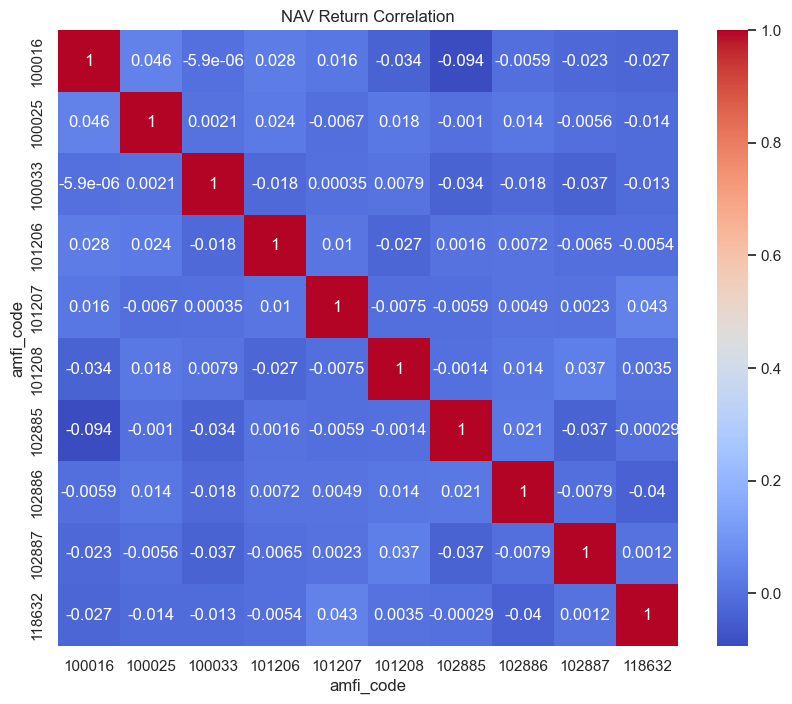

<Figure size 640x480 with 0 Axes>

In [50]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation")
plt.show()
save_chart("11_return_correlation.png")

In [51]:
sector = (
    holdings.groupby("sector")
    ["weight_pct"]
    .sum()
)

In [52]:
fig = go.Figure(
    data=[
        go.Pie(
            labels=sector.index,
            values=sector.values,
            hole=0.5
        )
    ]
)
fig.show()